In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

# Load your data
df = pd.read_csv('C:/Users/DELL/Downloads/Legal Case/processed_data/clean_legal_cases.csv')
df.head()

,Case_ID,Year,Court,Case_Text,Verdict,Legal_Citations,Case_Type,Sub_Type,Case_Name,Source_Folder,Case_Text_Full_Length,Num_Citations,Decision_Date,Docket_Number,First_Page,Last_Page
0,244,1959,Connecticut Superior Court,Cott Beverage Corporation v. Canada Dry Ginger...,Denied,135 Conn. 388; 143 Conn. 688; 21 Conn. Supp. 2...,Civil Procedure,Appeal,0244-01,fil3212,2421,10,1959-05-13,File No. 110292,244,246
1,400,1959,Connecticut Superior Court,Pamela Korn v. Marion R. Rennison Superior Cou...,Demurrer OVERRULED,122 Ga. 190; 139 Conn. 301; 15 Conn. Sup. 85; ...,Civil Procedure,Demurrer,0400-01,fil3212,6927,8,1959-11-12,File No. 90257,400,404
2,407,1959,Connecticut Superior Court,Zigmont Szestowicki v. Water Resources Commiss...,Judgment for Defendant,104 Conn. 382; 117 Conn. 462; 143 Conn. 109; 1...,Civil Procedure,Appeal,0407-01,fil3212,7147,11,1959-10-27,File No. 116941,407,411
3,55,1958,Connecticut Superior Court,Ralph H. Edson v. The Griffin Hospital et al. ...,Judgment for Defendant,127 Conn. 415; 154 Fla. 339; 157 Ill. 414; 186...,Civil Procedure,Pleading,0055-01,fil3212,16580,14,1958-03-27,File No. 85348,55,64
4,65,1958,Connecticut Superior Court,Hazel Hunt v. The Housing Authority of the Cit...,Demurrer OVERRULED,128 Conn. 132; 21 Conn. Supp. 65; 66 Conn. 387...,Civil Procedure,Demurrer,0065-01,fil3212,2306,7,1958-03-13,File No. 85343,65,66


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16033 entries, 0 to 16032
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Case_ID                16033 non-null  int64 
 1   Year                   16033 non-null  int64 
 2   Court                  16033 non-null  object
 3   Case_Text              16033 non-null  object
 4   Verdict                16033 non-null  object
 5   Legal_Citations        16033 non-null  object
 6   Case_Type              16033 non-null  object
 7   Sub_Type               16033 non-null  object
 8   Case_Name              16033 non-null  object
 9   Source_Folder          16033 non-null  object
 10  Case_Text_Full_Length  16033 non-null  int64 
 11  Num_Citations          16033 non-null  int64 
 12  Decision_Date          16033 non-null  object
 13  Docket_Number          8143 non-null   object
 14  First_Page             16033 non-null  int64 
 15  Last_Page          

In [3]:
# ============================================================
# CASE TYPE ANALYSIS (STATISTICS + UNIQUE VALUES)
# ============================================================

import pandas as pd

print("\n" + "=" * 70)
print("CASE TYPE ANALYSIS")
print("=" * 70)

# 1. Unique values
unique_case_types = df['Case_Type'].unique()
print(f"\nTotal Unique Case Types: {len(unique_case_types)}")
print("\nSample Case Types:")
print(unique_case_types[:20])  # show first 20 if many

# 2. Frequency distribution
case_type_dist = df['Case_Type'].value_counts(dropna=False)

# 3. Convert to structured table
case_type_table = pd.DataFrame({
    'Case_Type': case_type_dist.index,
    'Count': case_type_dist.values
})

case_type_table['Percentage'] = (
    case_type_table['Count'] / len(df) * 100
)

# 4. Print table
print("\nTop Case Types (Full Distribution):")
print(case_type_table)

# 5. Terminal-style visualization
print("\nDistribution Chart:")
for _, row in case_type_table.iterrows():
    bar = "█" * int(row['Percentage'] / 2)
    print(f"{row['Case_Type']:<35} {row['Count']:>6} ({row['Percentage']:5.1f}%) {bar}")

# 6. Basic stats
print("\nSummary Stats:")
print(f"Total rows: {len(df)}")
print(f"Unique case types: {df['Case_Type'].nunique()}")
print(f"Most common: {case_type_dist.idxmax()} ({case_type_dist.max()} cases)")
print(f"Least common: {case_type_dist.idxmin()} ({case_type_dist.min()} cases)")


CASE TYPE ANALYSIS

Total Unique Case Types: 7

Sample Case Types:
['Civil Procedure' 'Property Law - Ejectment' 'Contract Law - Debt'
 'Criminal Law' 'Torts' 'Torts - Defamation'
 'Property Law - Execution Sale']

Top Case Types (Full Distribution):
                       Case_Type  Count  Percentage
0                Civil Procedure   6352   39.618287
1            Contract Law - Debt   2547   15.885985
2       Property Law - Ejectment   2487   15.511757
3                   Criminal Law   2058   12.836026
4                          Torts   2039   12.717520
5  Property Law - Execution Sale    373    2.326452
6             Torts - Defamation    177    1.103973

Distribution Chart:
Civil Procedure                       6352 ( 39.6%) ███████████████████
Contract Law - Debt                   2547 ( 15.9%) ███████
Property Law - Ejectment              2487 ( 15.5%) ███████
Criminal Law                          2058 ( 12.8%) ██████
Torts                                 2039 ( 12.7%) ██████
P


Generating Case Type Visualization...


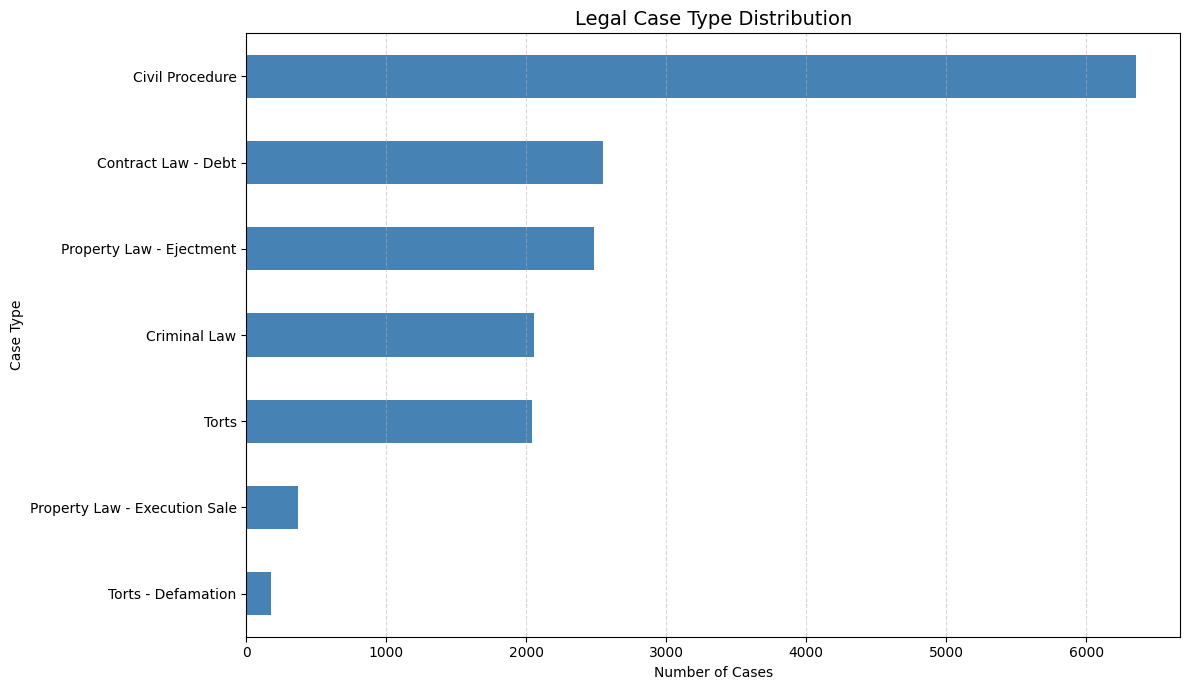

In [4]:
# ============================================================
# CASE TYPE VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

print("\nGenerating Case Type Visualization...")

# Get distribution
case_type_dist = df['Case_Type'].value_counts()

# Sort for better visualization
case_type_dist_sorted = case_type_dist.sort_values()

# Plot
plt.figure(figsize=(12, 7))

case_type_dist_sorted.plot(
    kind='barh',
    color='steelblue'
)

plt.title('Legal Case Type Distribution', fontsize=14)
plt.xlabel('Number of Cases')
plt.ylabel('Case Type')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# show
plt.show()

In [5]:
# ============================================================
# 4. CLEAN CASE TEXT (LEGAL NLP PREPROCESSING)
# ============================================================

def clean_legal_text(text):
    text = str(text).lower()
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = text.strip()
    return text

df['Case_Text'] = df['Case_Text'].apply(clean_legal_text)

In [6]:
# ============================================================
# 5. CASE TYPE MERGING
# ============================================================

case_type_mapping = {
    "Civil Procedure": "CIVIL",
    "Criminal Law": "CRIMINAL",
    "Contract Law - Debt": "CONTRACT",
    "Property Law - Ejectment": "PROPERTY",
    "Property Law - Execution Sale": "PROPERTY",
    "Torts - Defamation": "TORTS",
    "Torts": "TORTS"
}

# Create merged labels
df["Merged_Case_Type"] = df["Case_Type"].map(case_type_mapping)

# Check distribution
print("=" * 60)
print("MERGED CLASS DISTRIBUTION")
print("=" * 60)

print(df["Merged_Case_Type"].value_counts())

print("\nPercentage Distribution:\n")
print(df["Merged_Case_Type"].value_counts(normalize=True) * 100)

MERGED CLASS DISTRIBUTION
Merged_Case_Type
CIVIL       6352
PROPERTY    2860
CONTRACT    2547
TORTS       2216
CRIMINAL    2058
Name: count, dtype: int64

Percentage Distribution:

Merged_Case_Type
CIVIL       39.618287
PROPERTY    17.838209
CONTRACT    15.885985
TORTS       13.821493
CRIMINAL    12.836026
Name: proportion, dtype: float64


In [7]:
# ============================================================
# 7. LABEL ENCODING
# ============================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Convert text labels into numeric labels
df["Label"] = label_encoder.fit_transform(df["Merged_Case_Type"])

# Show mapping
print("=" * 60)
print("LABEL ENCODING MAPPING")
print("=" * 60)

for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} --> {i}")

LABEL ENCODING MAPPING
CIVIL --> 0
CONTRACT --> 1
CRIMINAL --> 2
PROPERTY --> 3
TORTS --> 4


In [8]:
# ============================================================
# 8. FEATURE & TARGET SPLIT
# ============================================================

# Text feature
X_text = df["Case_Text"]

# Numeric feature
X_numeric = df[["Case_Text_Full_Length"]]

# Target
y = df["Label"]

print("=" * 60)
print("FEATURE & TARGET INFO")
print("=" * 60)

print("Text Samples:", len(X_text))
print("Numeric Shape:", X_numeric.shape)
print("Labels:", len(y))

FEATURE & TARGET INFO
Text Samples: 16033
Numeric Shape: (16033, 1)
Labels: 16033


In [9]:
# ============================================================
# 9. TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

(
    X_text_train,
    X_text_test,
    X_num_train,
    X_num_test,
    y_train,
    y_test
) = train_test_split(
    X_text,
    X_numeric,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN TEST SPLIT COMPLETE")
print("=" * 60)

print("X_text_train:", X_text_train.shape)
print("X_text_test :", X_text_test.shape)
print("X_num_train :", X_num_train.shape)
print("X_num_test  :", X_num_test.shape)

TRAIN TEST SPLIT COMPLETE
X_text_train: (12826,)
X_text_test : (3207,)
X_num_train : (12826, 1)
X_num_test  : (3207, 1)


In [10]:
# ============================================================
# 10. TF-IDF VECTORIZATION
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=30000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

# Fit and transform training text
X_train_tfidf = tfidf_vectorizer.fit_transform(X_text_train)

# Transform test text
X_test_tfidf = tfidf_vectorizer.transform(X_text_test)

print("=" * 60)
print("TF-IDF COMPLETE")
print("=" * 60)

print("Train Shape:", X_train_tfidf.shape)
print("Test Shape :", X_test_tfidf.shape)

TF-IDF COMPLETE
Train Shape: (12826, 30000)
Test Shape : (3207, 30000)


In [11]:
# ============================================================
# 11. SCALE NUMERIC FEATURES
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_num_train_scaled = scaler.fit_transform(X_num_train)

X_num_test_scaled = scaler.transform(X_num_test)

print("=" * 60)
print("NUMERIC FEATURE SCALING COMPLETE")
print("=" * 60)
print(X_num_train_scaled.shape)

NUMERIC FEATURE SCALING COMPLETE
(12826, 1)


In [12]:
# ============================================================
# 12. COMBINE FEATURES
# ============================================================

from scipy.sparse import hstack

# Combine sparse TF-IDF with numeric features
X_train_combined = hstack([
    X_train_tfidf,
    X_num_train_scaled
])

X_test_combined = hstack([
    X_test_tfidf,
    X_num_test_scaled
])

print("=" * 60)
print("COMBINED FEATURE SHAPES")
print("=" * 60)

print("Train:", X_train_combined.shape)
print("Test :", X_test_combined.shape)

COMBINED FEATURE SHAPES
Train: (12826, 30001)
Test : (3207, 30001)


In [13]:
# ============================================================
# 13. APPLY SMOTE
# ============================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42,
    k_neighbors=3
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_combined,
    y_train
)

print("=" * 60)
print("SMOTE COMPLETE")
print("=" * 60)

print("Before SMOTE:", X_train_combined.shape)
print("After SMOTE :", X_train_smote.shape)

print("\nClass Distribution After SMOTE:\n")

import pandas as pd
print(pd.Series(y_train_smote).value_counts())

SMOTE COMPLETE
Before SMOTE: (12826, 30001)
After SMOTE : (25405, 30001)

Class Distribution After SMOTE:

Label
0    5081
4    5081
1    5081
2    5081
3    5081
Name: count, dtype: int64


In [14]:
# ============================================================
# 11. LOGISTIC REGRESSION MODEL
# ============================================================

from sklearn.linear_model import LogisticRegression

# Create model
lr_model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

# Train model
lr_model.fit(X_train_smote, y_train_smote)

print("=" * 60)
print("LOGISTIC REGRESSION TRAINING COMPLETE")
print("=" * 60) 
# ============================================================
# 12. LOGISTIC REGRESSION PREDICTION
# ============================================================

# Predict
lr_predictions = lr_model.predict(X_test_combined)

print(lr_predictions[:20])

print("=" * 60)
print("PREDICTION COMPLETE")
print("=" * 60)

LOGISTIC REGRESSION TRAINING COMPLETE
[4 3 0 0 0 4 3 3 0 2 1 0 3 1 3 0 4 4 0 0]
PREDICTION COMPLETE


In [15]:
# ============================================================
# 13. LOGISTIC REGRESSION EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)

print(f"Accuracy: {lr_accuracy:.4f}")

print("\nCLASSIFICATION REPORT\n")
print(
    classification_report(
        y_test,
        lr_predictions,
        target_names=label_encoder.classes_
    )
)

print("\nCONFUSION MATRIX\n")
print(confusion_matrix(y_test, lr_predictions))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.7848

CLASSIFICATION REPORT

              precision    recall  f1-score   support

       CIVIL       0.86      0.79      0.82      1271
    CONTRACT       0.72      0.72      0.72       509
    CRIMINAL       0.81      0.79      0.80       412
    PROPERTY       0.72      0.76      0.74       572
       TORTS       0.75      0.86      0.80       443

    accuracy                           0.78      3207
   macro avg       0.77      0.79      0.78      3207
weighted avg       0.79      0.78      0.79      3207


CONFUSION MATRIX

[[1008   92   30   96   45]
 [  61  365   13   61    9]
 [  23   12  326    8   43]
 [  52   32   20  436   32]
 [  32    9   13    7  382]]


In [16]:
# ============================================================
# 14. LINEAR SVM WITH SMOTE
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# ------------------------------------------------------------
# Feature Scaling for Sparse Matrix
# ------------------------------------------------------------
scaler = StandardScaler(with_mean=False)

X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test_combined)

# ------------------------------------------------------------
# Linear SVM Model
# ------------------------------------------------------------
svm_model = LinearSVC(
    max_iter=50000,
    dual=False
)

# ------------------------------------------------------------
# Train Model
# ------------------------------------------------------------
svm_model.fit(
    X_train_smote_scaled,
    y_train_smote
)

print("=" * 60)
print("SVM TRAINING COMPLETE")
print("=" * 60)

SVM TRAINING COMPLETE


In [17]:
# ============================================================
# 15. MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predict
predictions = svm_model.predict(X_test_combined)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("=" * 60)
print("SVM + SMOTE RESULTS")
print("=" * 60)

print(f"Accuracy: {accuracy:.4f}")

print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        y_test,
        predictions,
        target_names=label_encoder.classes_
    )
)

print("\nCONFUSION MATRIX\n")

print(confusion_matrix(y_test, predictions))

SVM + SMOTE RESULTS
Accuracy: 0.7247

CLASSIFICATION REPORT

              precision    recall  f1-score   support

       CIVIL       0.67      0.91      0.77      1271
    CONTRACT       0.76      0.50      0.60       509
    CRIMINAL       0.81      0.64      0.71       412
    PROPERTY       0.82      0.59      0.69       572
       TORTS       0.79      0.70      0.74       443

    accuracy                           0.72      3207
   macro avg       0.77      0.67      0.70      3207
weighted avg       0.74      0.72      0.72      3207


CONFUSION MATRIX

[[1157   41   24   33   16]
 [ 195  252   11   38   13]
 [ 108    9  263    4   28]
 [ 169   23   14  340   26]
 [ 110    7   14    0  312]]


In [18]:
# ============================================================
# 16. MODEL COMPARISON
# ============================================================

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        accuracy
    ]
})

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(comparison_df)

MODEL COMPARISON
                 Model  Accuracy
0  Logistic Regression  0.784846
1           Linear SVM  0.724665
